In [22]:
# Modules used for data handling.
import pandas as pd
import numpy as np
from numpy import expand_dims

# Modules used for data visualization.
import seaborn as sns
import matplotlib.pyplot as plt

# Module used to perform random choice from an iterable.
import random as r

# Modules used to build the MLP architecture
import keras
from keras.utils import to_categorical
from keras.models import Sequential
from keras.layers import Dense, Activation, MaxPooling2D, Conv2D, UpSampling2D, Input, Cropping2D
from tensorflow.keras.models import Model
from keras.datasets import mnist

sns.set_style()

In [23]:
class Dataset:

    def __init__(self):
        self.x_train = None
        self.y_train = None
        self.x_test = None
        self.y_test = None

    def load_dataset(self):
        (self.x_train, self.y_train), (self.x_test, self.y_test) = mnist.load_data()

    def show_samples(self):
        rows = 3
        columns = 8
        fig, axs = plt.subplots(rows, columns,figsize=(8,8))
        for i in range(rows):
            for j in range(columns):
                axs[i,j].imshow(r.choice(self.x_train),cmap='gray')
        fig.suptitle("Image Samples of MNIST dataset")
        plt.subplots_adjust(bottom=0.5, top=0.9, hspace=0)
        plt.show()

In [24]:
d = Dataset()

In [25]:
d.load_dataset()

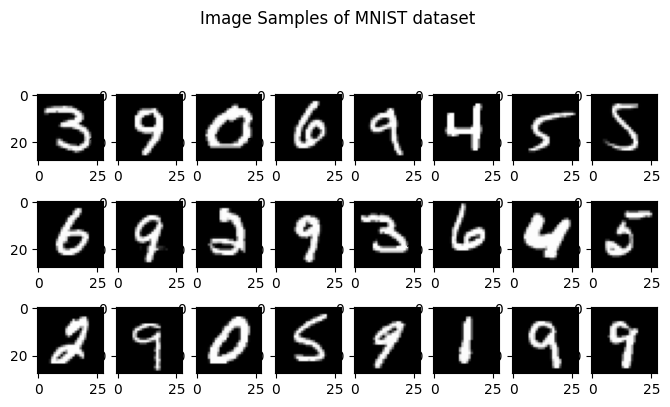

In [26]:
d.show_samples()

In [32]:
class Autoencoder:

    def __init__(self, x_train, y_train, x_test, y_test):
        self.x_train = x_train
        self.y_train = y_train
        self.x_test = x_test
        self.y_test = y_test

    def design_encoder(self):
        self.input = Input(shape=(28, 28, 1))

        self.x = Conv2D(16, (3, 3), activation='relu', padding='same')(self.input)
        self.x = MaxPooling2D((2, 2), padding='same')(self.x)

        self.x = Conv2D(8, (3, 3), activation='relu', padding='same')(self.x)
        self.x = MaxPooling2D((2, 2), padding='same')(self.x)

        self.x = Conv2D(8, (3, 3), activation='relu', padding='same')(self.x)
        self.encoded = MaxPooling2D((2, 2), padding='same')(self.x)

    def design_decoder(self):
        self.x = Conv2D(8, (3, 3), activation='relu', padding='same')(self.encoded)
        self.x = UpSampling2D((2, 2))(self.x)

        self.x = Conv2D(8, (3, 3), activation='relu', padding='same')(self.x)
        self.x = UpSampling2D((2, 2))(self.x)

        self.x = Conv2D(16, (3, 3), activation='relu', padding='same')(self.x)
        self.x = UpSampling2D((2, 2))(self.x)

        self.decoded = Conv2D(1, (3, 3), activation='sigmoid', padding='same')(self.x)

        # 32x32 output ko 28x28 banane ke liye
        self.decoded = Cropping2D(((2, 2), (2, 2)))(self.decoded)

    def compile_model(self):
        self.model = Model(self.input, self.decoded)
        self.model.compile(optimizer='adadelta', loss='binary_crossentropy')

    def fit_model(self):
        self.model.fit(
            self.x_train, self.x_train,
            epochs=20,
            batch_size=128,
            shuffle=True,
            validation_data=(self.x_test, self.x_test)
        )

In [33]:
# Autoencoder object
a = Autoencoder(d.x_train, d.y_train, d.x_test, d.y_test)

a.design_encoder()
a.design_decoder()
a.compile_model()

a.model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 28, 28, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 14, 14, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (None, 14, 14, 8)      │         1,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 7, 7, 8)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (None, 7, 7, 8)        │           584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 4, 4, 8)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_24 (Conv2D)              │ (None, 4, 4, 8)        │           584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_9 (UpSampling2D)  │ (None, 8, 8, 8)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_25 (Conv2D)              │ (None, 8, 8, 8)        │           584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_10 (UpSampling2D) │ (None, 16, 16, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_26 (Conv2D)              │ (None, 16, 16, 16)     │         1,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_11 (UpSampling2D) │ (None, 32, 32, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_27 (Conv2D)              │ (None, 32, 32, 1)      │           145 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cropping2d_3 (Cropping2D)       │ (None, 28, 28, 1)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,385 (17.13 KB)

 Trainable params: 4,385 (17.13 KB)

 Non-trainable params: 0 (0.00 B)

In [34]:
# Train model
a.fit_model()

Epoch 1/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - loss: -465.6315 - val_loss: -493.3953
Epoch 2/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: -496.6454 - val_loss: -513.7286
Epoch 3/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: -510.4809 - val_loss: -521.5573
Epoch 4/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: -515.2814 - val_loss: -523.8518
Epoch 5/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: -516.6725 - val_loss: -524.5718
Epoch 6/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: -517.2244 - val_loss: -525.0148
Epoch 7/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: -517.6465 - val_loss: -525.4048
Epoch 8/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: -518.0146 - val_loss: -525.7466
Epoch 9/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: -518.3441 - val_loss: -526.0563
Epoch 10/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: -518.6437 - val_loss: -526.3428
Epoch 11/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: -518.9193 - val_l

In [35]:
# Predict reconstructed images
decoded_imgs = a.model.predict(d.x_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step


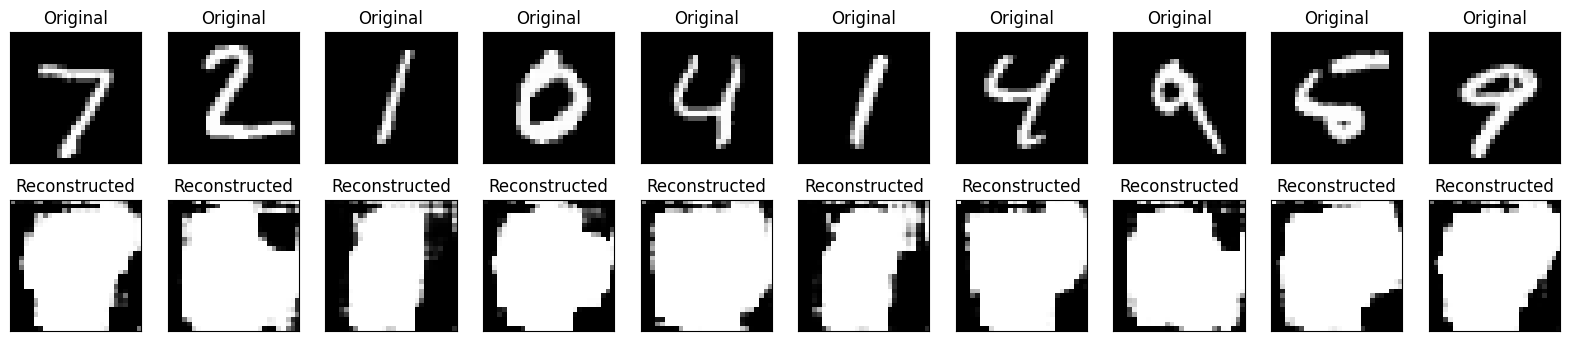

In [36]:
# Display original and reconstructed images
n = 10
plt.figure(figsize=(20, 4))

for i in range(n):
    # Original image
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(d.x_test[i].reshape(28, 28), cmap='gray')
    plt.title("Original")
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    # Reconstructed image
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_imgs[i].reshape(28, 28), cmap='gray')
    plt.title("Reconstructed")
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

plt.show()